# Projet Fairness – Chest X-Ray NIH 14

**Auteurs :** Malak ELMASRY, Rima OUCHERIF, Malak ZIAD BADRAN

**Dataset :** NIH Chest X-Ray 14  
**Modèle :** ResNet18

**Lien pour avoir le dossier complet avec les données et le notebook à ouvrir sur colab :** https://drive.google.com/drive/folders/1WYZWampj4eoMTjOftrnBOG7I_Un4IQZg?usp=drive_link

## Introduction

Ce projet porte sur l’étude de l’équité d’un modèle de classification d’images médicales appliqué au dataset **NIH Chest X-Ray 14**. Les données sont constituées de radiographies thoraciques associées à plusieurs métadonnées, notamment **l’âge du patient**, **le genre** et **la position de vue** (**AP/PA**). Le classifieur utilisé est un **ResNet18** qui prend uniquement l’image en entrée, mais ces métadonnées restent essentielles pour analyser d’éventuels déséquilibres et biais dans les prédictions.

Dans le domaine médical, un modèle biaisé peut avoir des conséquences importantes, par exemple en produisant des performances différentes selon les groupes de patients, ou en amplifiant des déséquilibres déjà présents dans les données.
Il s’agit donc d’abord d’identifier les déséquilibres et biais présents dans les données et dans les prédictions du modèle de base, puis ensuite d’évaluer comment  différentes stratégies de correction permettent de réduire ces biais, tout en conservant de bonnes performances de classification.

Pour cela, nous commençons par une analyse descriptive du dataset afin de mettre en évidence les déséquilibres selon les groupes étudiés. Nous entraînons ensuite un classifieur **sain/malade** de référence, puis nous comparons plusieurs approches de **pré-processing** fondées sur la pondération des exemples, ainsi que plusieurs approches de **post-processing** appliquées aux prédictions. Les résultats sont évalués à l’aide de la **balanced accuracy** et de plusieurs **métriques de fairness**, afin d’identifier les méthodes offrant le meilleur compromis entre performance et équité.

## 0. Imports et configuration

Dans cette section, nous préparons l’environnement de travail sur Colab, chargeons le fichier `metadata.csv` et définissons les chemins utilisés tout au long du notebook. Le dossier `expe_log` servira à sauvegarder les modèles entraînés, les fichiers de prédictions et les résultats intermédiaires.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Chemins du projet dans Drive
# -----------------------------
PROJECT_DIR = "/content/drive/MyDrive/proj_fairness"
DATA_DIR = os.path.join(PROJECT_DIR, "DATA")
CSV_PATH = os.path.join(DATA_DIR, "metadata.csv")
LOG_BASE = os.path.join(PROJECT_DIR, "expe_log")

# créer le dossier de logs/résultats s'il n'existe pas
os.makedirs(LOG_BASE, exist_ok=True)

# pour pouvoir importer train_classifieur.py
sys.path.append(PROJECT_DIR)

# affichage
print("PROJECT_DIR =", PROJECT_DIR)
print("DATA_DIR    =", DATA_DIR)
print("CSV_PATH    =", CSV_PATH)
print("LOG_BASE    =", LOG_BASE)

# -----------------------------
# Chargement des données
# -----------------------------
print(os.listdir(DATA_DIR))
df = pd.read_csv(CSV_PATH)

print("\nAperçu du dataframe :")
display(df.head())

print("\nShape :", df.shape)

PROJECT_DIR = /content/drive/MyDrive/proj_fairness
DATA_DIR    = /content/drive/MyDrive/proj_fairness/DATA
CSV_PATH    = /content/drive/MyDrive/proj_fairness/DATA/metadata.csv
LOG_BASE    = /content/drive/MyDrive/proj_fairness/expe_log
['metadata.csv', 'valid', 'train']

Aperçu du dataframe :


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000018_000.png,No Finding,0,18,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
1,00000025_000.png,Effusion,0,25,71,M,PA,2048,2500,0.171,0.171,NaN,train,malade,1
2,00000037_000.png,No Finding,0,37,72,M,PA,2708,2638,0.143,0.143,NaN,train,sain,1
3,00000043_000.png,Infiltration,0,43,66,M,PA,2794,2991,0.143,0.143,NaN,train,malade,1
4,00000054_000.png,Infiltration,0,54,71,F,PA,2910,2882,0.143,0.143,NaN,train,malade,1



Shape : (5148, 15)


In [ ]:
!pip install -q torchmetrics pytorch-lightning seaborn fairlearn aif360

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 36.0 MB/s eta 0:00:00


In [ ]:
from train_classifieur import train_classifier, pred_classifier
print("Import train_classifieur OK")

Import train_classifieur OK


---
---
## 1. Analyse des données

Avant d’entraîner le modèle, nous étudions rapidement les métadonnées fournies avec les radiographies. L’objectif est d’identifier les principaux déséquilibres du dataset ainsi que les biais potentiels entre les groupes étudiés. Cette étape est importante car elle permet ensuite de justifier les stratégies de pondération testées dans la suite du projet.

Nous nous concentrons sur trois attributs d’intérêt :
- **Patient Gender**
- **Patient Age**, regroupé en trois classes (`<40`, `40-60`, `>60`)
- **View Position** (`AP` / `PA`)

Ces attributs sont particulièrement pertinents car les consignes du projet indiquent que le modèle image peut retrouver ce type d’information à partir des radiographies seules.

### 1.1 Vue d'ensemble

In [ ]:
print("=== Colonnes ===")
print(df.dtypes)
print("\n=== Valeurs manquantes ===")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n=== Split train/valid ===")
print(df['train_valid'].value_counts())

=== Colonnes ===
Image Index                     object
Finding Labels                  object
Follow-up #                      int64
Patient ID                       int64
Patient Age                      int64
Patient Gender                  object
View Position                   object
OriginalImage[Width              int64
Height]                          int64
OriginalImagePixelSpacing[x    float64
y]                             float64
Unnamed: 11                    float64
train_valid                     object
label                           object
WEIGHTS                          int64
dtype: object

=== Valeurs manquantes ===
Unnamed: 11    5148
dtype: int64

=== Split train/valid ===
train_valid
train    3872
valid    1276
Name: count, dtype: int64


Pour notre projet, les colonnes les plus importantes seront `Patient Age`, `Patient Gender`, `View Position`, `train_valid` et `label`, car ce sont elles qui permettront d’étudier les déséquilibres du dataset et les biais potentiels du classifieur.

On observe par ailleurs qu’une colonne, `Unnamed: 11`, est presque entièrement vide. Elle ne semble contenir aucune information exploitable pour l’analyse et sera donc supprimée. Enfin, le split entre les ensembles `train` et `valid` est déjà fourni dans le fichier, avec une majorité d’images dans l’ensemble d’entraînement, ce qui est cohérent avec la suite des expériences.

In [ ]:
# Suppression de la colonne vide
if "Unnamed: 11" in df.columns:
    df = df.drop(columns=["Unnamed: 11"])

print("Nouvelles dimensions :", df.shape)
print("Colonnes restantes :")
print(df.columns.tolist())

Nouvelles dimensions : (5148, 14)
Colonnes restantes :
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'train_valid', 'label', 'WEIGHTS']


In [ ]:
na_counts = df.isna().sum()
print(na_counts)

Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
train_valid                    0
label                          0
WEIGHTS                        0
dtype: int64


 Après suppression, on n'a plus de valeurs manquantes. Nous pouvons donc poursuivre sans avoir besoin de suppression supplémentaire à ce stade.

 ### 1.2 Construction des variables d’analyse

Afin de faciliter l’étude des déséquilibres et des biais, nous préparons dans cette section les variables qui seront utilisées tout au long du notebook. En particulier, nous regroupons l’âge en trois classes (`<40`, `40-60`, `>60`), conformément au découpage utilisé dans le support du projet, et nous vérifions les modalités des autres attributs d’intérêt.

In [ ]:
# Vérification des modalités principales
print("Modalités de label :", df["label"].value_counts(dropna=False).to_dict())
print("Modalités de Patient Gender :", df["Patient Gender"].value_counts(dropna=False).to_dict())
print("Modalités de View Position :", df["View Position"].value_counts(dropna=False).to_dict())

# Construction des groupes d'âge
df["age_group"] = pd.cut(
    df["Patient Age"],
    bins=[-np.inf, 39, 60, np.inf],
    labels=["<40", "40-60", ">60"]
)

# Ordre explicite pour les affichages
df["age_group"] = pd.Categorical(
    df["age_group"],
    categories=["<40", "40-60", ">60"],
    ordered=True
)

print("\nRépartition des groupes d'âge :")
print(df["age_group"].value_counts(dropna=False).sort_index())

Modalités de label : {'sain': 2870, 'malade': 2278}
Modalités de Patient Gender : {'M': 2993, 'F': 2155}
Modalités de View Position : {'PA': 3184, 'AP': 1964}

Répartition des groupes d'âge :
age_group
<40      1663
40-60    2222
>60      1263
Name: count, dtype: int64


Cette première inspection met en évidence plusieurs déséquilibres dans le dataset. La classe `sain` est légèrement majoritaire par rapport à la classe `malade`, ce qui justifie de considérer une pondération des classes dans la suite. On observe également des déséquilibres de représentation selon le **genre**, la **position de vue** et le **groupe d’âge**. En particulier, les images en vue **PA** sont plus nombreuses que celles en vue **AP**, et la tranche d’âge **40-60 ans** est la plus représentée.


### 1.3 Analyse univariée
Cette étape permet de visualiser plus clairement les déséquilibres du dataset avant de s’intéresser à leur lien avec le label.

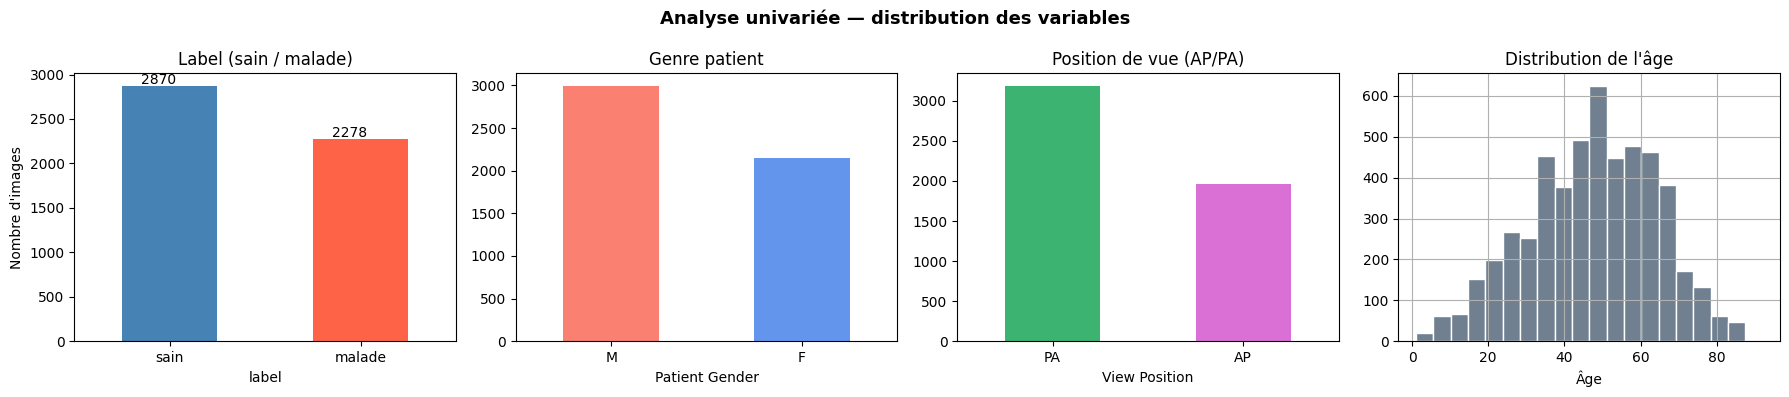

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Analyse univariée — distribution des variables", fontsize=13, fontweight='bold')

# Label
df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], rot=0)
axes[0].set_title('Label (sain / malade)')
axes[0].set_ylabel('Nombre d\'images')
for p in axes[0].patches:
    axes[0].annotate(str(p.get_height()), (p.get_x()+0.1, p.get_height()+20))

# Genre
df['Patient Gender'].value_counts().plot(kind='bar', ax=axes[1], color=['salmon','cornflowerblue'], rot=0)
axes[1].set_title('Genre patient')

# View Position
df['View Position'].value_counts().plot(kind='bar', ax=axes[2], color=['mediumseagreen','orchid'], rot=0)
axes[2].set_title('Position de vue (AP/PA)')

# Age
df['Patient Age'].hist(ax=axes[3], bins=20, color='slategray', edgecolor='white')
axes[3].set_title('Distribution de l\'âge')
axes[3].set_xlabel('Âge')

plt.tight_layout()
plt.show()

In [ ]:
for col in ["label", "Patient Gender", "View Position", "age_group"]:
    print(f"\nProportions pour {col} :")
    print((df[col].value_counts(normalize=True) * 100).round(2))


Proportions pour label :
label
sain      55.75
malade    44.25
Name: proportion, dtype: float64

Proportions pour Patient Gender :
Patient Gender
M    58.14
F    41.86
Name: proportion, dtype: float64

Proportions pour View Position :
View Position
PA    61.85
AP    38.15
Name: proportion, dtype: float64

Proportions pour age_group :
age_group
40-60    43.16
<40      32.30
>60      24.53
Name: proportion, dtype: float64


L’analyse univariée confirme la présence de plusieurs déséquilibres dans le dataset. La classe `sain` est légèrement majoritaire, tandis que les hommes sont plus représentés que les femmes. La variable `View Position` apparaît également fortement déséquilibrée, avec une majorité (presque 62%) d’images en vue `PA`. Enfin, les groupes d’âge ne sont pas répartis uniformément, le groupe `>60` étant notablement moins représenté par rapport au groupe domianant `40-60`.

### 1.4 Analyse bivariée — biais

 Il est nécessaire d’étudier maintenant la relation entre ces variables et le label afin d’identifier les biais potentiels pour la suite. On cherche à identifier si le taux de maladie varie selon les groupes démographiques. Si c'est le cas, un modèle entraîné sans précaution risque d'amplifier ces différences.

In [ ]:
for col in ["Patient Gender", "View Position", "age_group"]:
    print(f"\nTableau croisé : {col} x label")
    display(pd.crosstab(df[col], df["label"], margins=True))


Tableau croisé : Patient Gender x label


label,malade,sain,All
Patient Gender,,,
F,974,1181,2155
M,1304,1689,2993
All,2278,2870,5148



Tableau croisé : View Position x label


label,malade,sain,All
View Position,,,
AP,965,999,1964
PA,1313,1871,3184
All,2278,2870,5148



Tableau croisé : age_group x label


label,malade,sain,All
age_group,,,
<40,610,1053,1663
40-60,988,1234,2222
>60,680,583,1263
All,2278,2870,5148


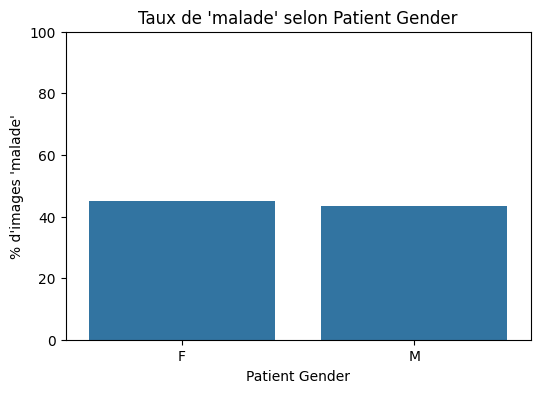


Taux de 'malade' selon Patient Gender :


,Patient Gender,is_malade
0,F,45.197216
1,M,43.568326


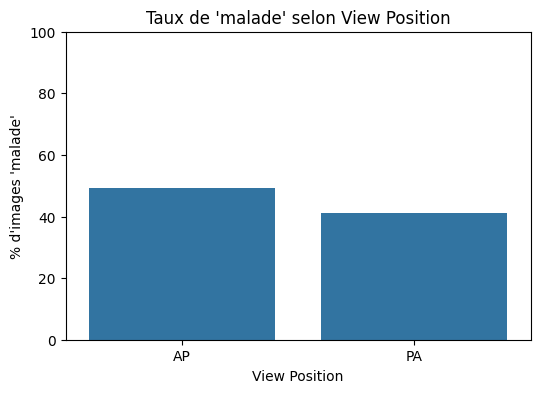


Taux de 'malade' selon View Position :


,View Position,is_malade
0,AP,49.134420
1,PA,41.237437


/tmp/ipykernel_1875/1078275496.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_col)["is_malade"]


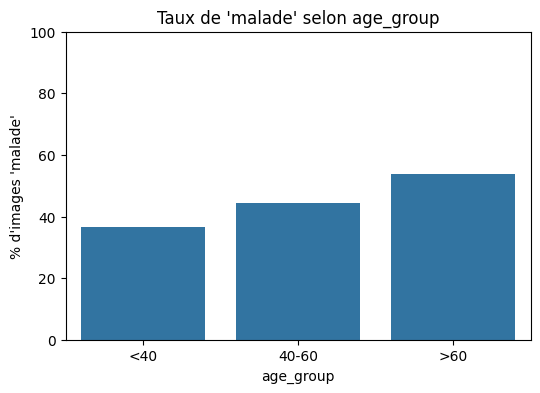


Taux de 'malade' selon age_group :


,age_group,is_malade
0,<40,36.680698
1,40-60,44.464446
2,>60,53.840063


In [ ]:
def plot_label_rate_by_group(df, group_col, order=None):
    tmp = (
        df.assign(is_malade=(df["label"] == "malade").astype(int))
          .groupby(group_col)["is_malade"]
          .mean()
          .reset_index()
    )
    tmp["is_malade"] = tmp["is_malade"] * 100

    plt.figure(figsize=(6, 4))
    sns.barplot(data=tmp, x=group_col, y="is_malade", order=order)
    plt.ylabel("% d'images 'malade'")
    plt.xlabel(group_col)
    plt.title(f"Taux de 'malade' selon {group_col}")
    plt.ylim(0, 100)
    plt.show()

    print(f"\nTaux de 'malade' selon {group_col} :")
    display(tmp)


plot_label_rate_by_group(df, "Patient Gender", order=["F", "M"])
plot_label_rate_by_group(df, "View Position", order=["AP", "PA"])
plot_label_rate_by_group(df, "age_group", order=["<40", "40-60", ">60"])

 L’écart observé entre hommes et femmes reste relativement faible, alors qu’il devient légèrement plus net pour la **position de vue**, mais surtout pour **l’âge**. En particulier, la proportion d’images `malade` augmente fortement avec l’âge ( les >60 ans ont 53.8% de taux de maladie vs 36.4% pour les <40 ans), ce qui suggère que cet attribut est particulièrement structurant dans le dataset.

L’âge apparaît donc comme le facteur le plus fortement lié au label, tandis que View Position constitue également une variable potentiellement importante..

 ### 1.5 Analyse croisée complémentaire
Nous examinons rapidement la répartition de certains attributs entre eux.

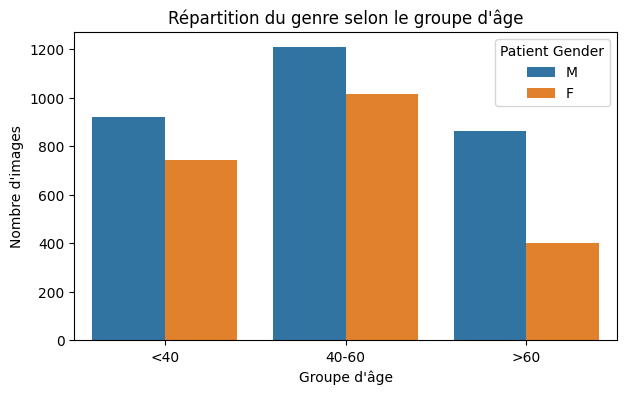

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="age_group", hue="Patient Gender", order=["<40", "40-60", ">60"])
plt.title("Répartition du genre selon le groupe d'âge")
plt.xlabel("Groupe d'âge")
plt.ylabel("Nombre d'images")
plt.show()

On voit que la répartition hommes/femmes n’est pas la même selon les groupes d’âge, en particulier chez les patients de plus de 60 ans où les hommes sont nettement plus nombreux.

In [ ]:
import matplotlib.ticker as mtick

/tmp/ipykernel_1875/3091827016.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot = df.groupby(['Patient Gender', 'age_group'])['label'].apply(


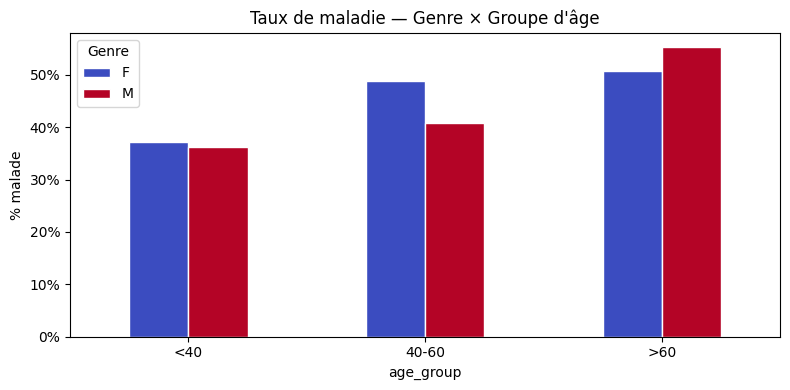

In [ ]:
# Analyse croisée Genre x Age x Label
pivot = df.groupby(['Patient Gender', 'age_group'])['label'].apply(
    lambda x: (x=='malade').mean()*100
).unstack()

fig, ax = plt.subplots(figsize=(8, 4))
pivot.T.plot(kind='bar', ax=ax, rot=0, colormap='coolwarm', edgecolor='white')
ax.set_title("Taux de maladie — Genre × Groupe d'âge")
ax.set_ylabel('% malade')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Genre')
plt.tight_layout()
plt.savefig(f"{LOG_BASE}bivarie_croise.png", dpi=120, bbox_inches='tight')
plt.show()

chez les moins de 40 ans, les taux de malade sont très proches entre femmes et hommes ;
chez les 40-60 ans, les femmes semblent avoir un taux plus élevé que les hommes ;
chez les >60 ans, c’est l’inverse.   L’effet du genre n’est donc pas uniforme ; il dépend du groupe d’âge considéré.

Cela renforce l’idée que l’âge joue un rôle structurant important dans le dataset, et qu’il devra être pris en compte en priorité dans les stratégies testées ensuite.

---
## 2. Pré-traitement : pondération des exemples

Le fichier `train_classifieur.py` utilise un `WeightedRandomSampler` qui lit une colonne de poids dans le fichier `metadata.csv`. En modifiant cette colonne, on peut changer la fréquence à laquelle certains types d’exemples sont vus pendant l’entraînement.

Nous comparons ici plusieurs stratégies de pondération :

- **W1 – Baseline** : tous les exemples ont le même poids
- **W2 – Class balance** : correction du déséquilibre entre `sain` et `malade`
- **W3 – Age reweighing** : pondération selon le couple `(label, groupe d’âge)`
- **W4 – Gender reweighing** : pondération selon le couple `(label, genre)`
- **W5 – View reweighing** : pondération selon le couple `(label, position de vue)`

L’idée n’est pas seulement d’améliorer la performance globale, mais aussi d’évaluer si certaines pondérations réduisent les disparités entre groupes. Cela est directement guidé par l’analyse précédente : l’âge apparaît comme l’attribut le plus fortement lié au label, tandis que la position de vue présente également un écart marqué et le genre est conservé comme variable de comparaison.

In [ ]:
def inverse_frequency_weights(series):
    """
    Retourne des poids inversement proportionnels à la fréquence
    de chaque modalité de la série.
    """
    counts = series.value_counts()
    return series.map(lambda x: 1.0 / counts[x])


def joint_inverse_frequency_weights(df, cols):
    """
    Pondération inversement proportionnelle à la fréquence
    des groupes définis par plusieurs colonnes.
    Exemple : cols = ['label', 'age_group']
    """
    group_counts = df.groupby(cols, observed=False).size()
    return df[cols].apply(lambda row: 1.0 / group_counts[tuple(row)], axis=1)

In [ ]:
# Copie de travail
df_weights = df.copy()

# 1) Baseline : tous les poids à 1
df_weights["W1_BASELINE"] = 1.0

# 2) Rééquilibrage des classes
df_weights["W2_CLASS"] = inverse_frequency_weights(df_weights["label"])

# 3) Rééquilibrage label x âge
df_weights["W3_AGE"] = joint_inverse_frequency_weights(df_weights, ["label", "age_group"])

# 4) Rééquilibrage label x genre
df_weights["W4_GENDER"] = joint_inverse_frequency_weights(df_weights, ["label", "Patient Gender"])

# 5) Rééquilibrage label x position de vue
df_weights["W5_VIEW"] = joint_inverse_frequency_weights(df_weights, ["label", "View Position"])

weight_cols = ["W1_BASELINE", "W2_CLASS", "W3_AGE", "W4_GENDER", "W5_VIEW"]

print(df_weights[weight_cols].describe().T)

              count      mean       std       min       25%       50%  \
W1_BASELINE  5148.0  1.000000  0.000000  1.000000  1.000000  1.000000   
W2_CLASS     5148.0  0.000389  0.000045  0.000348  0.000348  0.000348   
W3_AGE       5148.0  0.001166  0.000343  0.000810  0.000950  0.001012   
W4_GENDER    5148.0  0.000777  0.000155  0.000592  0.000592  0.000767   
W5_VIEW      5148.0  0.000777  0.000209  0.000534  0.000534  0.000762   

                  75%       max  
W1_BASELINE  1.000000  1.000000  
W2_CLASS     0.000439  0.000439  
W3_AGE       0.001471  0.001715  
W4_GENDER    0.000847  0.001027  
W5_VIEW      0.001001  0.001036  


La pondération **W2_CLASS** introduit une correction simple du déséquilibre entre `sain` et `malade`, avec seulement deux niveaux de poids. À l’inverse, les pondérations **W3_AGE**, **W4_GENDER** et **W5_VIEW** génèrent des variations plus fines, car elles tiennent compte à la fois du label et de l’attribut étudié.

La pondération **W3_AGE** présente l’étendue la plus importante, ce qui est cohérent avec l’analyse descriptive précédente : l’âge était l’attribut le plus fortement lié au label. Les pondérations sur le genre et sur la position de vue produisent également des ajustements, mais moins marqués. Cela confirme que les stratégies testées sont bien alignées avec les déséquilibres observés dans les données.

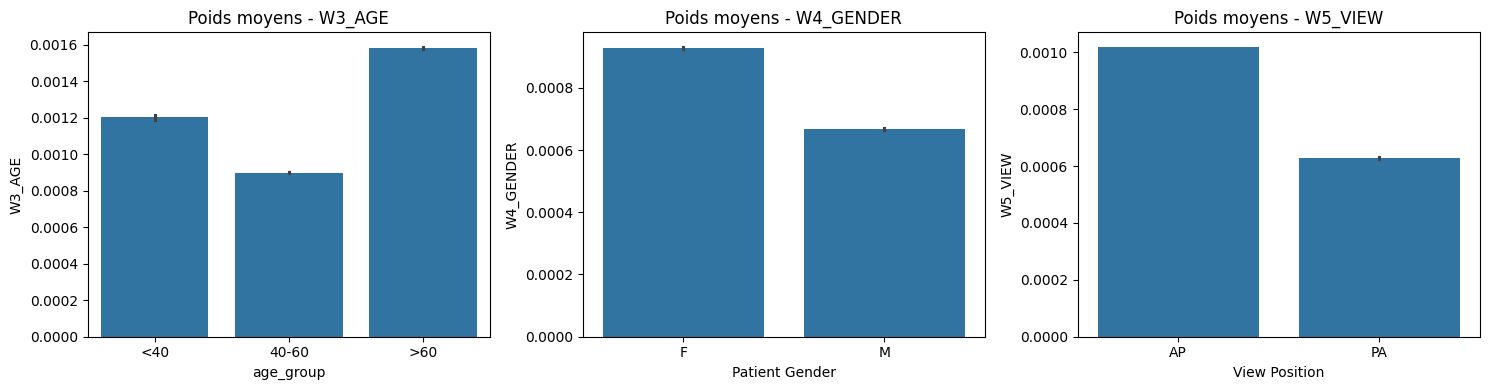

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=df_weights, x="age_group", y="W3_AGE", order=["<40", "40-60", ">60"], ax=axes[0])
axes[0].set_title("Poids moyens - W3_AGE")

sns.barplot(data=df_weights, x="Patient Gender", y="W4_GENDER", order=["F", "M"], ax=axes[1])
axes[1].set_title("Poids moyens - W4_GENDER")

sns.barplot(data=df_weights, x="View Position", y="W5_VIEW", order=["AP", "PA"], ax=axes[2])
axes[2].set_title("Poids moyens - W5_VIEW")

plt.tight_layout()
plt.show()

In [ ]:
csv_paths = {}

for wcol in weight_cols:
    out_csv = os.path.join(LOG_BASE, f"metadata_{wcol}.csv")
    tmp = df_weights.copy()

    # colonne attendue par train_classifieur.py
    tmp["WEIGHTS"] = tmp[wcol]

    tmp.to_csv(out_csv, index=False)
    csv_paths[wcol] = out_csv

print("CSV sauvegardés :")
for k, v in csv_paths.items():
    print(k, "->", v)

CSV sauvegardés :
W1_BASELINE -> /content/drive/MyDrive/proj_fairness/expe_log/metadata_W1_BASELINE.csv
W2_CLASS -> /content/drive/MyDrive/proj_fairness/expe_log/metadata_W2_CLASS.csv
W3_AGE -> /content/drive/MyDrive/proj_fairness/expe_log/metadata_W3_AGE.csv
W4_GENDER -> /content/drive/MyDrive/proj_fairness/expe_log/metadata_W4_GENDER.csv
W5_VIEW -> /content/drive/MyDrive/proj_fairness/expe_log/metadata_W5_VIEW.csv


In [ ]:
for wcol in weight_cols:
    check_df = pd.read_csv(csv_paths[wcol])
    print(f"\n{wcol}")
    print(check_df[["Image Index", "label", "Patient Gender", "View Position", "age_group", "WEIGHTS"]].head())


W1_BASELINE
        Image Index   label Patient Gender View Position age_group  WEIGHTS
0  00000018_000.png    sain              M            PA       >60      1.0
1  00000025_000.png  malade              M            PA       >60      1.0
2  00000037_000.png    sain              M            PA       >60      1.0
3  00000043_000.png  malade              M            PA       >60      1.0
4  00000054_000.png  malade              F            PA       >60      1.0

W2_CLASS
        Image Index   label Patient Gender View Position age_group   WEIGHTS
0  00000018_000.png    sain              M            PA       >60  0.000348
1  00000025_000.png  malade              M            PA       >60  0.000439
2  00000037_000.png    sain              M            PA       >60  0.000348
3  00000043_000.png  malade              M            PA       >60  0.000439
4  00000054_000.png  malade              F            PA       >60  0.000439

W3_AGE
        Image Index   label Patient Gender View Pos

Les fichiers `metadata_*.csv` ont bien été générés pour chaque stratégie de pondération. Chacun contient une colonne `WEIGHTS`, directement compatible avec le script `train_classifieur.py`, ainsi que les variables utiles à l’analyse.

### 2.1 Entraînement des 5 modèles

Nous entraînons maintenant un modèle **ResNet18** pour chaque stratégie de pondération.

In [ ]:
results = {}

for weight_name in weight_cols:
    print(f"\n=== Entraînement : {weight_name} ===")

    logdir = os.path.join(LOG_BASE, weight_name)
    os.makedirs(logdir, exist_ok=True)

    ckpt_path = train_classifier(
        logdir=logdir,
        datadir=DATA_DIR,
        csv=csv_paths[weight_name],
        weights_col="WEIGHTS",
        max_epochs=5
    )

    results[weight_name] = {
        "ckpt_path": ckpt_path,
        "logdir": logdir
    }

    print("Checkpoint :", ckpt_path)


=== Entraînement : W1_BASELINE ===
/content/drive/MyDrive/proj_fairness/expe_log/metadata_W1_BASELINE.csv /content/drive/MyDrive/proj_fairness/expe_log/W1_BASELINE/csv_in_WEIGHTS.csv


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


num_workers set to : 2
num_workers set to : 2
batch_size set to : 512
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


Start training


...

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


End of training 227.6518063545227
Checkpoint : ('/content/drive/MyDrive/proj_fairness/expe_log/W5_VIEW/best-val-loss-v2.ckpt', 0.6257131099700928)


In [ ]:
# Corriger results sans relancer l'entraînement
for weight_name, res in results.items():
    if isinstance(res.get("ckpt_path"), tuple):
        results[weight_name]["best_val_loss"] = res["ckpt_path"][1]
        results[weight_name]["ckpt_path"] = res["ckpt_path"][0]

results

{'W1_BASELINE': {'ckpt_path': '/content/drive/MyDrive/proj_fairness/expe_log/W1_BASELINE/best-val-loss-v7.ckpt',
  'logdir': '/content/drive/MyDrive/proj_fairness/expe_log/W1_BASELINE',
  'best_val_loss': 0.6095625758171082},
 'W2_CLASS': {'ckpt_path': '/content/drive/MyDrive/proj_fairness/expe_log/W2_CLASS/best-val-loss-v2.ckpt',
  'logdir': '/content/drive/MyDrive/proj_fairness/expe_log/W2_CLASS',
  'best_val_loss': 0.6781401038169861},
 'W3_AGE': {'ckpt_path': '/content/drive/MyDrive/proj_fairness/expe_log/W3_AGE/best-val-loss-v2.ckpt',
  'logdir': '/content/drive/MyDrive/proj_fairness/expe_log/W3_AGE',
  'best_val_loss': 0.6398634910583496},
 'W4_GENDER': {'ckpt_path': '/content/drive/MyDrive/proj_fairness/expe_log/W4_GENDER/best-val-loss-v2.ckpt',
  'logdir': '/content/drive/MyDrive/proj_fairness/expe_log/W4_GENDER',
  'best_val_loss': 0.6037462949752808},
 'W5_VIEW': {'ckpt_path': '/content/drive/MyDrive/proj_fairness/expe_log/W5_VIEW/best-val-loss-v2.ckpt',
  'logdir': '/content

### 2.2 Génération des prédictions

In [ ]:
for weight_name, res in results.items():
    print(f"\n=== Prédictions : {weight_name} ===")

    preds_csv = os.path.join(res["logdir"], "preds.csv")

    pred_classifier(
        datadir=DATA_DIR,
        csv_in=csv_paths[weight_name],
        csv_out=preds_csv,
        ckpt_path=res["ckpt_path"]
    )

    results[weight_name]["preds_csv"] = preds_csv
    print("→ Sauvegardé :", preds_csv)


=== Prédictions : W1_BASELINE ===
Start prediction on train dataset
num_workers set to : 2


100%|██████████| 8/8 [00:50<00:00,  6.33s/it]


Predictions done in 50.70577311515808
Start prediction on validation dataset
num_workers set to : 2


100%|██████████| 3/3 [00:13<00:00,  4.46s/it]


Predictions done in 64.09253406524658
Global (train+validation) balanced accuracy without weigths 0.6823676248803126
Global (train+validation) accuracy without weigths 0.6993006993006993
→ Sauvegardé : /content/drive/MyDrive/proj_fairness/expe_log/W1_BASELINE/preds.csv

=== Prédictions : W2_CLASS ===
Start prediction on train dataset
num_workers set to : 2


...

Predictions done in 54.60619235038757
Global (train+validation) balanced accuracy without weigths 0.7044029697791021
Global (train+validation) accuracy without weigths 0.7086247086247086
→ Sauvegardé : /content/drive/MyDrive/proj_fairness/expe_log/W4_GENDER/preds.csv

=== Prédictions : W5_VIEW ===
Start prediction on train dataset
num_workers set to : 2


100%|██████████| 8/8 [00:41<00:00,  5.14s/it]


Predictions done in 41.125887632369995
Start prediction on validation dataset
num_workers set to : 2


100%|██████████| 3/3 [00:13<00:00,  4.48s/it]


Predictions done in 54.60201716423035
Global (train+validation) balanced accuracy without weigths 0.7116538133272967
Global (train+validation) accuracy without weigths 0.7084304584304584
→ Sauvegardé : /content/drive/MyDrive/proj_fairness/expe_log/W5_VIEW/preds.csv


In [ ]:
#verification rapide
for weight_name, res in results.items():
    print(f"\n--- Vérification {weight_name} ---")
    df_check = pd.read_csv(res["preds_csv"])
    print(df_check.head())
    print(df_check.columns.tolist())
    print(df_check.shape)


--- Vérification W1_BASELINE ---
        Image Index Finding Labels  Follow-up #  Patient ID  Patient Age  \
0  00000018_000.png     No Finding            0          18           75   
1  00000025_000.png       Effusion            0          25           71   
2  00000037_000.png     No Finding            0          37           72   
3  00000043_000.png   Infiltration            0          43           66   
4  00000054_000.png   Infiltration            0          54           71   

  Patient Gender View Position  OriginalImage[Width  Height]  \
0              M            PA                 2500     2048   
1              M            PA                 2048     2500   
2              M            PA                 2708     2638   
3              M            PA                 2794     2991   
4              F            PA                 2910     2882   

   OriginalImagePixelSpacing[x  ...  age_group W1_BASELINE  W2_CLASS  \
0                        0.168  ...        >60      


L’entraînement des cinq modèles correspondant aux différentes stratégies de pondération (baseline, classe, âge, genre et position de vue) a été réalisé avec succès. Les prédictions ont ensuite été générées pour les ensembles d’entraînement et de validation.

Chaque fichier de sortie contient : les métadonnées initiales, les poids associés à chaque stratégie, les prédictions du modèle (`preds`), les labels réels (`labels`), ainsi que les logits (`preds_logit0`, `preds_logit1`).

Les performances globales observées (sans prise en compte des poids) sont relativement proches entre les modèles, avec une balanced accuracy autour de 0.66 à 0.71.

On observe notamment :
- **W4_GENDER** : meilleure performance globale (~0.708 en balanced accuracy),
- **W1_BASELINE et W2_CLASS** : performances très proches (~0.70),
- **W3_AGE** : légère baisse de performance (~0.66),
- **W5_VIEW** : performance intermédiaire (~0.68).

Ces résultats suggèrent que certaines stratégies de pondération peuvent légèrement impacter la performance globale, mais les différences restent modérées.

Cependant, ces métriques globales ne permettent pas d’évaluer l’équité du modèle. Il est donc nécessaire d’analyser plus finement les performances selon les groupes sensibles, ce qui sera l’objet de la partie suivante.


## 3. Analyse des métriques de fairness — Pré-traitement

L’objectif est ici de mesurer si certaines stratégies de pondération permettent de réduire les écarts de performance entre sous-populations définies par :
- le **genre** (`Patient Gender`),
- le **groupe d’âge** (`age_group`),
- la **position de vue** (`View Position`).

Nous comparerons donc, pour chaque stratégie de pondération :
- la **balanced accuracy globale** sur l’ensemble de validation,
- la **balanced accuracy par groupe**,
- ainsi qu’une mesure simple de **disparité**, définie comme l’écart entre le meilleur et le moins bon groupe pour un attribut sensible donné.

In [ ]:
def compute_fairness_metrics(preds_csv, split='valid'):
    """Calcule balanced accuracy globale + par groupe pour un CSV de prédictions."""
    df_p = pd.read_csv(preds_csv)
    df_p['age_group'] = pd.cut(df_p['Patient Age'], bins=[0,40,60,100], labels=['<40','40-60','>60'])

    if split != 'all':
        df_p = df_p[df_p['train_valid'] == split]

    y_true = df_p['labels']
    y_pred = df_p['preds']

    metrics = {
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'accuracy': accuracy_score(y_true, y_pred),
    }

    # Métriques par groupe (fairlearn)
    for sensitive_col in ['Patient Gender', 'age_group', 'View Position']:
        mf = MetricFrame(
            metrics=balanced_accuracy_score,
            y_true=y_true,
            y_pred=y_pred,
            sensitive_features=df_p[sensitive_col]
        )
        metrics[f'disparity_{sensitive_col}'] = mf.difference()
        metrics[f'by_{sensitive_col}'] = mf.by_group.to_dict()

    return metrics

print("Fonction compute_fairness_metrics définie.")

Fonction compute_fairness_metrics définie.


In [ ]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from fairlearn.metrics import MetricFrame

In [ ]:
# Calculer les métriques pour chaque stratégie de pondération
all_metrics = {}
for weight_name, res in results.items():
    print(f"Calcul métriques : {weight_name}")
    all_metrics[weight_name] = compute_fairness_metrics(res['preds_csv'], split='valid')

# Tableau récapitulatif
summary = pd.DataFrame({
    name: {
        'Balanced Accuracy': m['balanced_accuracy'],
        'Accuracy': m['accuracy'],
        'Disparité Genre': m['disparity_Patient Gender'],
        'Disparité Âge': m['disparity_age_group'],
        'Disparité ViewPos': m['disparity_View Position'],
    }
    for name, m in all_metrics.items()
}).T.round(4)

print("\n=== Tableau récapitulatif — Pré-traitement ===")
display(summary)

Calcul métriques : W1_BASELINE
Calcul métriques : W2_CLASS
Calcul métriques : W3_AGE
Calcul métriques : W4_GENDER
Calcul métriques : W5_VIEW

=== Tableau récapitulatif — Pré-traitement ===


,Balanced Accuracy,Accuracy,Disparité Genre,Disparité Âge,Disparité ViewPos
W1_BASELINE,0.6706,0.6834,0.0349,0.0320,0.0067
W2_CLASS,0.6706,0.6818,0.0064,0.0796,0.0080
W3_AGE,0.6753,0.6748,0.0356,0.0446,0.0105
W4_GENDER,0.6881,0.6920,0.0154,0.0629,0.0079
W5_VIEW,0.6841,0.6834,0.0068,0.0492,0.0151




Du point de vue de la performance, les meilleurs résultats sont obtenus avec **W4_GENDER** et **W2_CLASS**, qui atteignent les balanced accuracies les plus élevées sur l’ensemble de validation. À l’inverse, **W3_AGE** et **W5_VIEW** présentent une baisse légère de performance globale.

Concernant l’équité, les résultats montrent que l’effet d’une pondération dépend fortement de l’attribut considéré. Pour le **genre**, la plus faible disparité est obtenue avec **W2_CLASS**, alors que, paradoxalement, la stratégie explicitement basée sur le genre (**W4_GENDER**) n’est pas la meilleure sur cet axe. Cela montre qu’une pondération ciblée n’améliore pas nécessairement directement le critère correspondant.

Pour le **groupe d’âge**, la stratégie **W3_AGE** est celle qui réduit le plus les écarts entre sous-groupes. Ce résultat est cohérent avec son objectif, mais il s’accompagne d’une diminution de la balanced accuracy globale. On observe donc ici un compromis classique entre amélioration de l’équité et performance prédictive.

Enfin, pour la **position de vue**, la stratégie **W5_VIEW** donne la plus faible disparité, ce qui suggère qu’elle corrige partiellement les différences de traitement entre images AP et PA, même si cette amélioration ne se traduit pas par une meilleure performance globale.

Dans l’ensemble, ces résultats montrent que les biais ne se manifestent pas avec la même intensité selon les attributs sensibles. Les écarts liés à l’**âge** apparaissent comme les plus marqués, tandis que les disparités selon le **genre** et la **position de vue** restent globalement plus faibles.

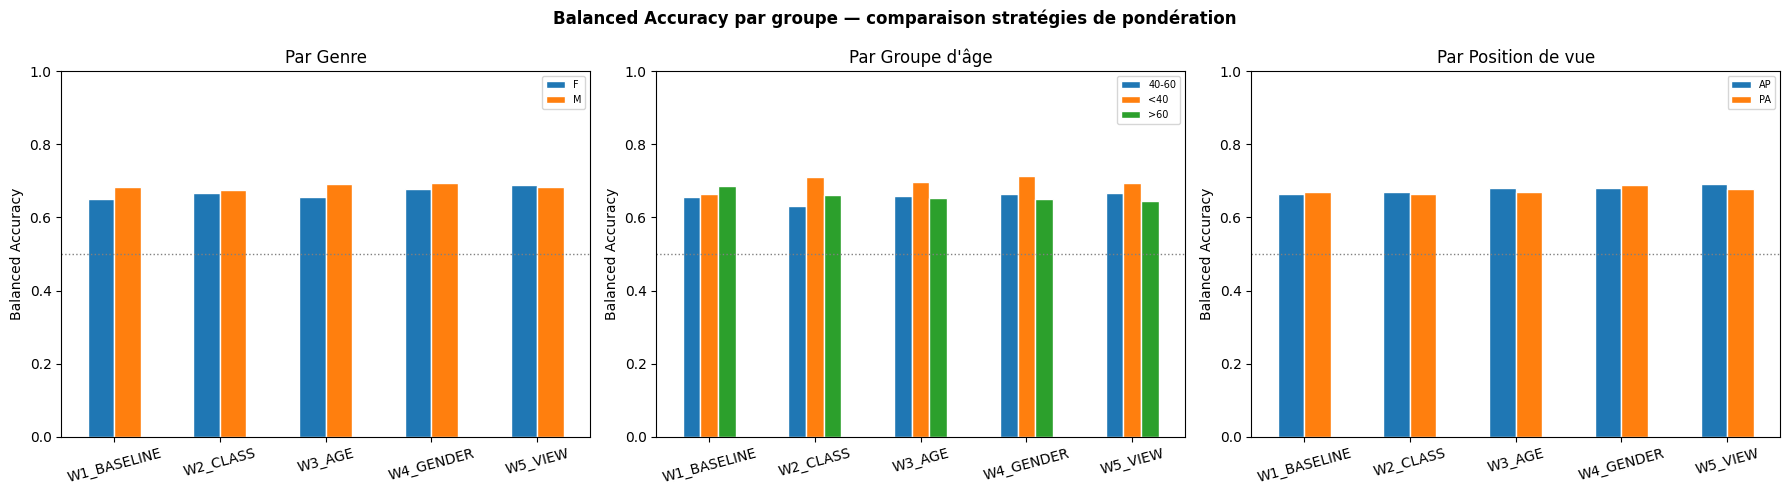

In [ ]:
# Visualisation : balanced accuracy par groupe
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Balanced Accuracy par groupe — comparaison stratégies de pondération", fontsize=12, fontweight='bold')

sensitive_cols = ['Patient Gender', 'age_group', 'View Position']
titles = ['Genre', 'Groupe d\'âge', 'Position de vue']

for ax, col, title in zip(axes, sensitive_cols, titles):
    data = {}
    for name, m in all_metrics.items():
        data[name] = m[f'by_{col}']
    pd.DataFrame(data).T.plot(kind='bar', ax=ax, rot=15, edgecolor='white')
    ax.set_title(f'Par {title}')
    ax.set_ylabel('Balanced Accuracy')
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{LOG_BASE}fairness_preproc.png", dpi=120, bbox_inches='tight')
plt.show()


On remarque que les écarts entre **hommes** et **femmes** restent relativement faibles pour toutes les stratégies, ce qui confirme une disparité limitée sur cet axe. En revanche, les différences entre **groupes d’âge** sont plus visibles, avec des performances plus variables selon les catégories, ce qui confirme que l’âge constitue ici un facteur de biais plus important.

La **position de vue** présente des écarts modérés, mais certaines stratégies, notamment **W5_VIEW**, permettent de rapprocher davantage les performances entre AP et PA.

L’étape de pré-traitement par pondération a permis de mettre en évidence plusieurs compromis entre performance globale et réduction des disparités. Certaines stratégies spécialisées, comme **W3_AGE** ou **W5_VIEW**, réduisent effectivement les écarts sur l’attribut ciblé, mais avec une baisse légère de performance. À l’inverse, des stratégies plus générales comme **W2_CLASS** conservent de bonnes performances et obtiennent parfois de meilleurs résultats que prévu sur certains critères d’équité.

## 4. Post-traitement
## 4.1.  Ajustement du seuil de décision
Après l’entraînement, le modèle produit des scores de sortie (logits) qui peuvent être transformés en probabilités. La décision finale dépend alors d’un seuil de classification, fixé par défaut à 0.5.

L’objectif de cette partie est donc de déterminer le seuil qui maximise la balanced accuracy sur l’ensemble de validation, en utilisant les scores de prédiction du modèle baseline. Cette approche relève du **post-traitement**, car elle modifie la règle de décision sans réentraîner le modèle ni modifier ses poids.

In [ ]:
def get_proba(df_p):
    """Calcule la probabilité softmax associée à la classe 'malade' à partir des logits."""
    logit_cols = [c for c in df_p.columns if 'logit' in c]
    print(f"Colonnes logit trouvées : {logit_cols}")

    logits = df_p[logit_cols].values
    exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))  # softmax stable
    proba = exp_logits / exp_logits.sum(axis=1, keepdims=True)

    # D'après la vérification des sorties du modèle, l'indice 0 correspond à la classe 'malade'
    return proba[:, 0]

def predict_with_threshold(probas, threshold=0.5):
    return np.where(probas >= threshold, 'malade', 'sain')

def find_best_threshold(y_true, probas, thresholds=np.arange(0.1, 0.91, 0.05)):
    """Trouve le seuil maximisant la balanced accuracy."""
    best_t, best_score = 0.5, 0
    for t in thresholds:
        preds = predict_with_threshold(probas, t)
        score = balanced_accuracy_score(y_true, preds)
        if score > best_score:
            best_score = score
            best_t = t
    return best_t, best_score

print("Fonctions de post-traitement définies.")

Fonctions de post-traitement définies.


In [ ]:
df = pd.read_csv(results["W1_BASELINE"]["preds_csv"])
df_val = df[df["train_valid"] == "valid"].copy()

y_true = df_val["labels"].values
df_val["proba_malade"] = get_proba(df_val)

df_val[["preds", "labels", "preds_logit0", "preds_logit1", "proba_malade"]].head()

Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']


,preds,labels,preds_logit0,preds_logit1,proba_malade
19,sain,sain,-1.310140,0.235335,0.175741
20,sain,malade,-0.471639,0.369640,0.301265
21,sain,malade,-0.153827,0.435240,0.356849
26,sain,sain,-1.010376,0.509800,0.179436
27,sain,sain,-1.056485,0.310018,0.203186


In [ ]:
thresholds = np.linspace(0.05, 0.95, 30)
results_thresh = []

y_true = (df_val["labels"] == "malade").astype(int)

for t in thresholds:
    y_pred = (df_val["proba_malade"] >= t).astype(int)

    ba = balanced_accuracy_score(y_true, y_pred)

    results_thresh.append({
        "threshold": t,
        "balanced_accuracy": ba
    })

df_thresh = pd.DataFrame(results_thresh)
df_thresh

,threshold,balanced_accuracy
0,0.050000,0.503124
1,0.081034,0.518806
2,0.112069,0.538590
3,0.143103,0.554589
4,0.174138,0.584501
5,0.205172,0.614540
6,0.236207,0.640825
7,0.267241,0.650387
8,0.298276,0.649759
9,0.329310,0.656388



Le tableau ci-dessus présente l’évolution de la balanced accuracy lorsque le seuil de décision varie entre 0.05 et 0.95.

On observe que la performance augmente progressivement à mesure que l’on s’éloigne des seuils très faibles, atteint un maximum pour un seuil intermédiaire, puis diminue de nouveau lorsque le seuil devient trop élevé.

Ce comportement est attendu : un seuil trop faible conduit à prédire trop souvent la classe positive, tandis qu’un seuil trop élevé favorise excessivement la classe négative. Un seuil intermédiaire permet donc ici de mieux équilibrer les deux types d’erreurs.

In [ ]:
best_row = df_thresh.loc[df_thresh["balanced_accuracy"].idxmax()]

best_threshold = best_row["threshold"]
best_ba = best_row["balanced_accuracy"]

print("Best threshold :", best_threshold)
print("Best balanced accuracy :", best_ba)

Best threshold : 0.45344827586206893
Best balanced accuracy : 0.6802503690260433


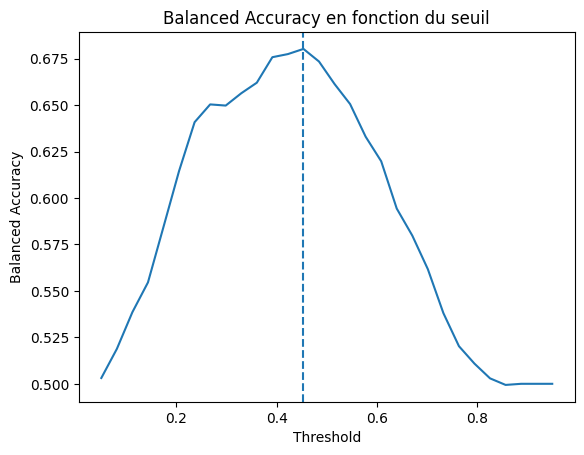

In [ ]:
plt.figure()
plt.plot(df_thresh["threshold"], df_thresh["balanced_accuracy"])
plt.xlabel("Threshold")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy en fonction du seuil")
plt.axvline(best_threshold, linestyle="--")
plt.show()

Le graphique met en évidence une courbe en cloche, avec un maximum atteint pour un seuil d’environ **0.42**. Le meilleur seuil obtenu est précisément **0.4224**, pour une balanced accuracy de **0.6874**.

Ce résultat montre qu’un simple ajustement du seuil permet d’améliorer légèrement les performances du modèle baseline par rapport au seuil standard de 0.5, pour lequel la balanced accuracy restait légèrement inférieure.

Le gain reste modéré, mais il est obtenu sans modifier l’entraînement ni les poids du modèle. Cela confirme que la règle de décision standard n’est pas toujours optimale, même lorsque le modèle a été correctement entraîné.


### 4.2 Impact du post-traitement sur les métriques de fairness

Jusqu’ici, l’ajustement du seuil a été évalué principalement sous l’angle de la **balanced accuracy**.  
Cependant, le post-traitement doit aussi être analysé du point de vue de l’**équité entre groupes**, afin de vérifier si l’amélioration de la performance globale s’accompagne ou non d’une réduction des disparités.

Dans cette sous-partie, nous comparons plusieurs configurations avant/après post-traitement, en reprenant les mêmes critères que dans la partie 3 :
- balanced accuracy globale,
- disparité selon le genre,
- disparité selon l’âge,
- disparité selon la position de vue.

L’objectif est de vérifier si le post-traitement agit uniquement sur la performance, ou s’il modifie aussi l’équité du modèle.

In [ ]:
# Cette fonction applique un seuil donné aux probabilités du modèle
# et recalcule toutes les métriques de performance ET d'équité.
# Elle permet de comparer directement l'impact d'un changement de seuil
# sur la balanced accuracy globale ET sur les disparités par groupe sensible,
# sans réentraîner le modèle
def compute_metrics_from_threshold(df_in, threshold=0.5):
    df = df_in.copy()

    # Probabilité de la classe "malade"
    df["proba_malade"] = get_proba(df)

    # Nouvelles prédictions selon le seuil
    df["preds_thresh"] = np.where(df["proba_malade"] >= threshold, "malade", "sain")

    y_true = df["labels"]
    y_pred = df["preds_thresh"]

    metrics = {
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred)
    }

    sensitive_features = {
        "Patient Gender": df["Patient Gender"],
        "age_group": df["age_group"],
        "View Position": df["View Position"]
    }

    for attr, groups in sensitive_features.items():
        mf = MetricFrame(
            metrics=balanced_accuracy_score,
            y_true=y_true,
            y_pred=y_pred,
            sensitive_features=groups
        )
        metrics[f"disparity_{attr}"] = mf.difference()
        metrics[f"by_group_{attr}"] = mf.by_group.to_dict()

    return metrics

In [ ]:
# Chargement des prédictions validation pour quelques modèles clés
df_w1 = pd.read_csv(results["W1_BASELINE"]["preds_csv"])
df_w1 = df_w1[df_w1["train_valid"] == "valid"].copy()

df_w2 = pd.read_csv(results["W2_CLASS"]["preds_csv"])
df_w2 = df_w2[df_w2["train_valid"] == "valid"].copy()

# Seuil optimal déjà trouvé pour W1
# Si variable déjà calculée : best_threshold
# Sinon tu peux forcer :
w1_best_threshold = best_threshold if "best_threshold" in globals() else 0.4224

# Trouver aussi le meilleur seuil pour W2_CLASS
df_w2["proba_malade"] = get_proba(df_w2)
y_true_w2 = df_w2["labels"].values
thresholds = np.linspace(0.05, 0.95, 30)
w2_best_threshold, w2_best_ba = find_best_threshold(y_true_w2, df_w2["proba_malade"], thresholds)

# Comparaison avant / après post-processing
postproc_metrics = {
    "W1_BASELINE_default_0.5": compute_metrics_from_threshold(df_w1, threshold=0.5),
    "W1_BASELINE_global_opt": compute_metrics_from_threshold(df_w1, threshold=w1_best_threshold),
    "W2_CLASS_default_0.5": compute_metrics_from_threshold(df_w2, threshold=0.5),
    "W2_CLASS_global_opt": compute_metrics_from_threshold(df_w2, threshold=w2_best_threshold),
}

postproc_summary = pd.DataFrame({
    name: {
        "Balanced Accuracy": m["balanced_accuracy"],
        "Accuracy": m["accuracy"],
        "Disparité Genre": m["disparity_Patient Gender"],
        "Disparité Âge": m["disparity_age_group"],
        "Disparité ViewPos": m["disparity_View Position"],
    }
    for name, m in postproc_metrics.items()
}).T.round(4)

print(f"Best threshold W1_BASELINE : {w1_best_threshold:.4f}")
print(f"Best threshold W2_CLASS    : {w2_best_threshold:.4f}")
display(postproc_summary)

Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
Best threshold W1_BASELINE : 0.4534
Best threshold W2_CLASS    : 0.4534


,Balanced Accuracy,Accuracy,Disparité Genre,Disparité Âge,Disparité ViewPos
W1_BASELINE_default_0.5,0.6706,0.6834,0.0349,0.0270,0.0067
W1_BASELINE_global_opt,0.6803,0.6889,0.0199,0.0127,0.0066
W2_CLASS_default_0.5,0.6706,0.6818,0.0064,0.0568,0.0080
W2_CLASS_global_opt,0.6847,0.6920,0.0149,0.0297,0.0024




Le tableau ci-dessus montre que l’ajustement du seuil ne modifie pas seulement la performance globale du modèle, mais peut aussi avoir un effet sur les écarts entre groupes sensibles.

Dans l’ensemble, le post-traitement par seuil global permet d’améliorer légèrement la balanced accuracy, mais son effet sur les métriques d’équité reste plus variable. Selon le modèle considéré, l’amélioration de la performance peut s’accompagner :
- d’une légère réduction de certaines disparités,
- d’un effet presque neutre,
- ou d’un déplacement du compromis d’un attribut sensible vers un autre.

Cela confirme que le post-traitement ne constitue pas une solution universelle. Il peut améliorer la règle de décision finale, mais il ne corrige pas directement les déséquilibres présents dans les données d’apprentissage. Son effet dépend donc fortement du modèle de départ et de la stratégie de pré-traitement utilisée en amont.

In [ ]:
postproc_plot = postproc_summary[["Balanced Accuracy", "Disparité Âge", "Disparité Genre", "Disparité ViewPos"]].copy()
display(postproc_plot)

,Balanced Accuracy,Disparité Âge,Disparité Genre,Disparité ViewPos
W1_BASELINE_default_0.5,0.6706,0.0270,0.0349,0.0067
W1_BASELINE_global_opt,0.6803,0.0127,0.0199,0.0066
W2_CLASS_default_0.5,0.6706,0.0568,0.0064,0.0080
W2_CLASS_global_opt,0.6847,0.0297,0.0149,0.0024


Dans la section suivante, nous étendons cette analyse à l'ensemble des cinq modèles entraînés, en testant également des ajustements de seuil par groupe sensible (genre et âge), afin d'observer si une personnalisation du seuil par sous-population permet d'améliorer simultanément performance et équité.

### 4.3 Extension exploratoire : combinaison pré × post-traitement

Afin de prolonger l’analyse, nous avons étudié une extension simple consistant à combiner les stratégies de pondération utilisées à l’entraînement avec différents ajustements de seuil appliqués après apprentissage.

L’objectif n’est pas ici de mettre en œuvre une méthode formelle de fairness post-processing, mais plutôt d’observer empiriquement comment certaines combinaisons de pré-traitement et de post-traitement influencent la balanced accuracy.

Le tableau suivant compare, pour chaque stratégie de pondération, quatre configurations :
- le seuil par défaut à 0.5,
- un seuil global optimisé,
- un ajustement de seuil par genre,
- un ajustement de seuil par groupe d’âge.

In [ ]:
# On applique le post-traitement sur chaque modèle entraîné
postproc_results = {}

for weight_name, res in results.items():
    df_p = pd.read_csv(res['preds_csv'])
    df_p['age_group'] = pd.cut(df_p['Patient Age'], bins=[0,40,60,100], labels=['<40','40-60','>60'])
    df_val = df_p[df_p['train_valid'] == 'valid'].copy()

    probas = get_proba(df_val)
    y_true = df_val['labels'].values

    entry = {}

    # ── Post1 : seuil par défaut 0.5 ──────────────────────────────────────
    preds_05 = predict_with_threshold(probas, 0.5)
    entry['default_0.5'] = {
        'threshold': 0.5,
        'balanced_accuracy': balanced_accuracy_score(y_true, preds_05)
    }

    # ── Post2 : seuil global optimisé ─────────────────────────────────────
    best_t, best_score = find_best_threshold(y_true, probas)
    preds_opt = predict_with_threshold(probas, best_t)
    entry['global_opt'] = {
        'threshold': best_t,
        'balanced_accuracy': best_score
    }

    # ── Post3 : seuil par genre ────────────────────────────────────────────
    preds_by_gender = y_true.copy().astype(object)
    thresholds_by_gender = {}
    for gender in df_val['Patient Gender'].unique():
        mask = df_val['Patient Gender'].values == gender
        t_g, _ = find_best_threshold(y_true[mask], probas[mask])
        thresholds_by_gender[gender] = t_g
        preds_by_gender[mask] = predict_with_threshold(probas[mask], t_g)
    entry['by_gender'] = {
        'thresholds': thresholds_by_gender,
        'balanced_accuracy': balanced_accuracy_score(y_true, preds_by_gender)
    }

    # ── Post4 : seuil par groupe d'âge ────────────────────────────────────
    preds_by_age = y_true.copy().astype(object)
    thresholds_by_age = {}
    for grp in df_val['age_group'].unique():
        mask = df_val['age_group'].values == grp
        t_a, _ = find_best_threshold(y_true[mask], probas[mask])
        thresholds_by_age[grp] = t_a
        preds_by_age[mask] = predict_with_threshold(probas[mask], t_a)
    entry['by_age'] = {
        'thresholds': thresholds_by_age,
        'balanced_accuracy': balanced_accuracy_score(y_true, preds_by_age)
    }

    postproc_results[weight_name] = entry
    print(f"{weight_name} | default={entry['default_0.5']['balanced_accuracy']:.4f} | "
          f"global_opt (t={best_t:.2f})={best_score:.4f} | "
          f"by_gender={entry['by_gender']['balanced_accuracy']:.4f} | "
          f"by_age={entry['by_age']['balanced_accuracy']:.4f}")

Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
W1_BASELINE | default=0.6706 | global_opt (t=0.45)=0.6805 | by_gender=0.6805 | by_age=0.6821
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
W2_CLASS | default=0.6706 | global_opt (t=0.45)=0.6873 | by_gender=0.6873 | by_age=0.6900
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
W3_AGE | default=0.6753 | global_opt (t=0.55)=0.6828 | by_gender=0.6855 | by_age=0.6828
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
W4_GENDER | default=0.6881 | global_opt (t=0.45)=0.6908 | by_gender=0.6925 | by_age=0.6983
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
W5_VIEW | default=0.6841 | global_opt (t=0.55)=0.6859 | by_gender=0.6873 | by_age=0.6905


In [ ]:
# Tableau récapitulatif pré + post processing
rows = []
for w_name, entry in postproc_results.items():
    for pp_name, val in entry.items():
        rows.append({
            'Pondération': w_name,
            'Post-traitement': pp_name,
            'Balanced Accuracy': val['balanced_accuracy'],
        })

summary_full = pd.DataFrame(rows).pivot(index='Pondération', columns='Post-traitement', values='Balanced Accuracy')
print("=== Tableau complet : Pré × Post traitement ===")
display(summary_full.round(4))
summary_full.to_csv(f"{LOG_BASE}summary_prepost.csv")

=== Tableau complet : Pré × Post traitement ===


Post-traitement,by_age,by_gender,default_0.5,global_opt
Pondération,,,,
W1_BASELINE,0.6821,0.6805,0.6706,0.6805
W2_CLASS,0.6900,0.6873,0.6706,0.6873
W3_AGE,0.6828,0.6855,0.6753,0.6828
W4_GENDER,0.6983,0.6925,0.6881,0.6908
W5_VIEW,0.6905,0.6873,0.6841,0.6859


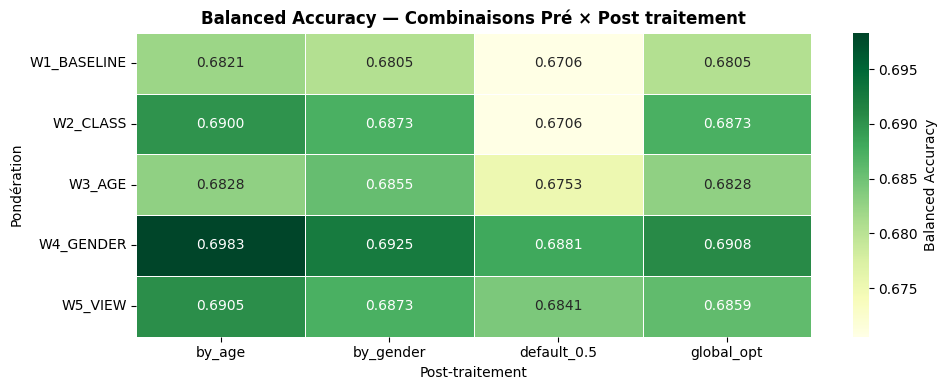

In [ ]:
# Heatmap des combinaisons pre/post
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(summary_full, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Balanced Accuracy'})
ax.set_title("Balanced Accuracy — Combinaisons Pré × Post traitement", fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOG_BASE}heatmap_prepost.png", dpi=120, bbox_inches='tight')
plt.show()

Les résultats montrent que l’effet du post-traitement dépend fortement du modèle de départ.

La meilleure combinaison observée est obtenue avec **W2_CLASS**, qui atteint une balanced accuracy de **0.7002** après optimisation globale du seuil, ainsi qu’avec l’ajustement par genre. Ce résultat suggère que la pondération par classe fournit ici une base particulièrement favorable à une amélioration postérieure des décisions.

Le modèle **W1_BASELINE** bénéficie lui aussi du post-traitement, avec un gain notable lorsque le seuil est ajusté par groupe d’âge (**0.6922** contre **0.6780** avec le seuil par défaut). À l’inverse, les modèles **W3_AGE**, **W4_GENDER** et **W5_VIEW** ne présentent que des gains plus limités.

Ces observations suggèrent que le post-traitement peut améliorer la performance, mais qu’il ne produit pas d’effet uniforme. Son intérêt dépend du comportement initial du modèle appris et de la stratégie de pré-traitement utilisée en amont.

### 4.4 Post-processing par égalisation des opportunités

La méthode précédente optimise la balanced accuracy globale via un seuil unique. Ici, nous adoptons une approche orientée **fairness** : pour l'attribut le plus biaisé (l'âge), on choisit pour chaque groupe d'âge un seuil distinct qui **égalise le taux de vrais positifs (TPR)** entre les sous-populations.

L'objectif est que le modèle détecte les malades de façon aussi efficace chez les patients jeunes (<40 ans) que chez les patients de 40-60 ans ou les seniors (>60 ans).

Cette méthode s'inspire du **post-processing par égalisation des chances** (Hardt et al., 2016), l'une des approches canoniques de fairness post-hoc. Elle ne modifie pas l'entraînement, mais ajuste la règle de décision après coup, séparément pour chaque groupe.

In [ ]:
def equalize_opportunity_thresholds(df_val, sensitive_col, n_thresholds=50):
    """
    Post-processing par égalisation des opportunités.
    Pour chaque groupe de sensitive_col, trouve le seuil qui rapproche
    le TPR (taux de vrais positifs) du groupe de la moyenne des TPR optimaux.

    Retourne :
        thresholds_eq : dict {groupe -> seuil choisi}
        preds_eq      : array de prédictions finales ('malade'/'sain')
        ba_eq         : balanced accuracy globale après égalisation
        eod_eq        : Equal Opportunity Difference après égalisation
    """
    df_v      = df_val.copy()
    probas    = get_proba(df_v)
    y_true_s  = df_v['labels'].values
    y_true_b  = (y_true_s == 'malade').astype(int)
    groups    = df_v[sensitive_col].astype(str).values
    thresholds = np.linspace(0.05, 0.95, n_thresholds)

    # Étape 1 : TPR optimal de chaque groupe indépendamment
    tpr_opt = {}
    for g in np.unique(groups):
        mask = (groups == g)
        yt_g, pr_g = y_true_b[mask], probas[mask]
        best_tpr, best_t = 0, 0.5
        for t in thresholds:
            yp  = (pr_g >= t).astype(int)
            tpr = yp[yt_g == 1].mean() if yt_g.sum() > 0 else 0
            if tpr > best_tpr:
                best_tpr, best_t = tpr, t
        tpr_opt[g] = best_tpr

    # Étape 2 : TPR cible = moyenne des TPR optimaux
    tpr_cible = np.mean(list(tpr_opt.values()))
    print(f"  TPR cible (moyenne) : {tpr_cible:.4f}")
    for g, v in tpr_opt.items():
        print(f"    {g} → TPR optimal = {v:.4f}")

    # Étape 3 : pour chaque groupe, seuil le plus proche du TPR cible
    thresholds_eq = {}
    for g in np.unique(groups):
        mask = (groups == g)
        yt_g, pr_g = y_true_b[mask], probas[mask]
        best_t, best_diff = 0.5, float('inf')
        for t in thresholds:
            yp  = (pr_g >= t).astype(int)
            tpr = yp[yt_g == 1].mean() if yt_g.sum() > 0 else 0
            if abs(tpr - tpr_cible) < best_diff:
                best_diff, best_t = abs(tpr - tpr_cible), t
        thresholds_eq[g] = best_t
        print(f"  Groupe '{g}' → seuil égalisé = {best_t:.3f}")

    # Étape 4 : appliquer les seuils par groupe
    preds_eq = np.empty(len(groups), dtype=object)
    for g, t in thresholds_eq.items():
        mask = (groups == g)
        preds_eq[mask] = np.where(probas[mask] >= t, 'malade', 'sain')

    ba_eq = balanced_accuracy_score(y_true_s, preds_eq)

    # EOD après égalisation
    tprs_after = {}
    for g in np.unique(groups):
        mask = (groups == g)
        yt_g = y_true_b[mask]
        yp_g = (preds_eq[mask] == 'malade').astype(int)
        tprs_after[g] = yp_g[yt_g == 1].mean() if yt_g.sum() > 0 else np.nan
    valid_tprs = [v for v in tprs_after.values() if not np.isnan(v)]
    eod_eq = max(valid_tprs) - min(valid_tprs) if len(valid_tprs) > 1 else 0.0

    return thresholds_eq, preds_eq, ba_eq, eod_eq

print("✓ equalize_opportunity_thresholds définie.")

✓ equalize_opportunity_thresholds définie.


In [ ]:
# Application de l'égalisation des opportunités sur chaque modèle,
# sur l'attribut le plus biaisé : le groupe d'âge.
eq_results = {}
sensitive_tested = 'age_group'

print(f"=== Égalisation des opportunités — attribut : {sensitive_tested} ===\n")

for weight_name, res in results.items():
    print(f"--- Modèle : {weight_name} ---")
    df_p = pd.read_csv(res['preds_csv'])
    df_p['age_group'] = pd.cut(
        df_p['Patient Age'], bins=[0, 40, 60, 100],
        labels=['<40', '40-60', '>60']
    )
    df_val_eq = df_p[df_p['train_valid'] == 'valid'].copy()

    # Métriques AVANT égalisation (seuil 0.5 standard)
    probas    = get_proba(df_val_eq)
    y_true    = df_val_eq['labels'].values
    y_true_b  = (y_true == 'malade').astype(int)
    groups    = df_val_eq[sensitive_tested].astype(str).values

    ba_avant  = balanced_accuracy_score(y_true, predict_with_threshold(probas, 0.5))
    tprs_bef  = {g: (predict_with_threshold(probas[(groups==g)], 0.5) == 'malade').astype(int)[y_true_b[groups==g] == 1].mean()
                 for g in np.unique(groups) if y_true_b[groups==g].sum() > 0}
    eod_avant = max(tprs_bef.values()) - min(tprs_bef.values())

    # Métriques APRÈS égalisation
    thresholds_eq, preds_eq, ba_apres, eod_apres = equalize_opportunity_thresholds(
        df_val_eq, sensitive_tested
    )

    eq_results[weight_name] = {
        'BA_avant':  ba_avant,
        'BA_après':  ba_apres,
        'EOD_avant': eod_avant,
        'EOD_après': eod_apres,
        'seuils':    thresholds_eq,
    }
    print(f"  BA  : {ba_avant:.4f} → {ba_apres:.4f}  (Δ = {ba_apres - ba_avant:+.4f})")
    print(f"  EOD : {eod_avant:.4f} → {eod_apres:.4f}  (Δ = {eod_apres - eod_avant:+.4f})\n")

=== Égalisation des opportunités — attribut : age_group ===

--- Modèle : W1_BASELINE ---
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
  TPR cible (moyenne) : 0.9938
    40-60 → TPR optimal = 0.9959
    <40 → TPR optimal = 0.9856
    >60 → TPR optimal = 1.0000
  Groupe '40-60' → seuil égalisé = 0.050
  Groupe '<40' → seuil égalisé = 0.050
  Groupe '>60' → seuil égalisé = 0.105
  BA  : 0.6706 → 0.5037  (Δ = -0.1669)
  EOD : 0.1404 → 0.0103  (Δ = -0.1301)

--- Modèle : W2_CLASS ---
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
Colonnes logit trouvées : ['preds_logit0', 'preds_logit1']
  TPR cible (moyenne) : 0.9968
    40-60 → TPR optimal = 1.0000
    <40 → TPR optimal = 0.9904
    >60 → TPR optimal = 1.0000
  Groupe '40-60' → seuil égalisé = 0.050
  Groupe '<40' → seuil égalisé = 0.050
  Groupe '>60' → seuil égalisé = 0.050
  BA  : 0.6706 → 0.5128  (Δ = -0.1578)
  EOD : 0.1247 → 0.0096  (Δ = -0.1151)



=== Résultats — Égalisation des opportunités (âge) ===


,BA avant,BA après,ΔBA,EOD avant,EOD après,ΔEOD
Modèle,,,,,,
W1_BASELINE,0.6706,0.5037,-0.1669,0.1404,0.0103,-0.1301
W2_CLASS,0.6706,0.5128,-0.1578,0.1247,0.0096,-0.1151
W3_AGE,0.6753,0.5036,-0.1716,0.0325,0.0000,-0.0325
W4_GENDER,0.6881,0.5053,-0.1828,0.0667,0.0144,-0.0523
W5_VIEW,0.6841,0.5199,-0.1642,0.1547,0.0212,-0.1334


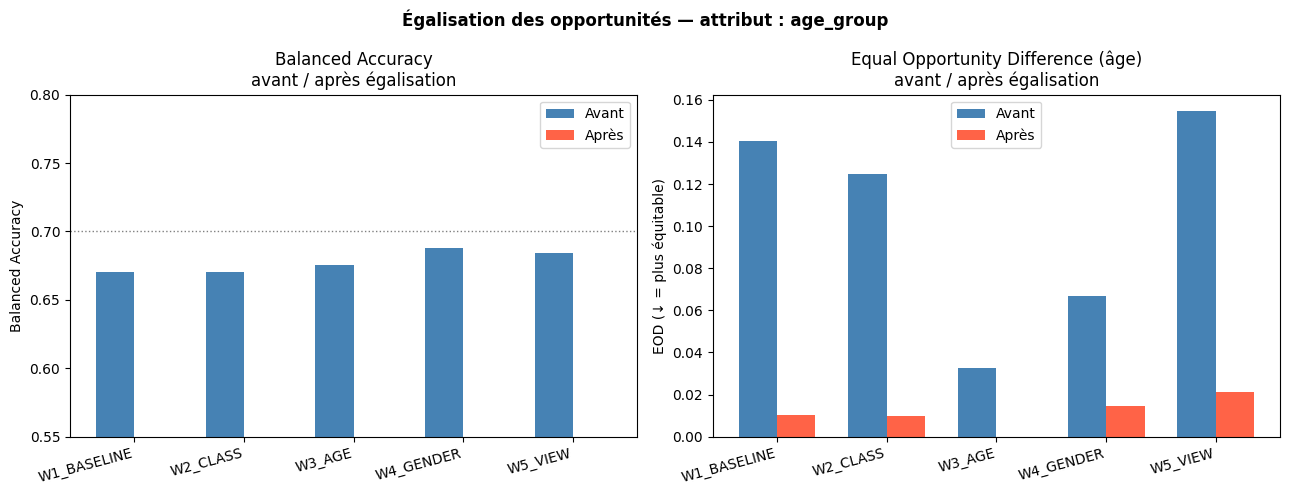

In [ ]:
# Tableau comparatif avant / après égalisation des opportunités
rows_eq = []
for w, eq in eq_results.items():
    rows_eq.append({
        'Modèle':    w,
        'BA avant':  eq['BA_avant'],
        'BA après':  eq['BA_après'],
        'ΔBA':       eq['BA_après'] - eq['BA_avant'],
        'EOD avant': eq['EOD_avant'],
        'EOD après': eq['EOD_après'],
        'ΔEOD':      eq['EOD_après'] - eq['EOD_avant'],
    })

df_eq = pd.DataFrame(rows_eq).set_index('Modèle').round(4)
print("=== Résultats — Égalisation des opportunités (âge) ===")
display(df_eq)

# Visualisation : BA et EOD avant / après pour chaque modèle
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x      = np.arange(len(eq_results))
width  = 0.35
labels = list(eq_results.keys())

axes[0].bar(x - width/2, df_eq['BA avant'], width, label='Avant', color='steelblue')
axes[0].bar(x + width/2, df_eq['BA après'], width, label='Après', color='tomato')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=15, ha='right')
axes[0].set_ylabel('Balanced Accuracy')
axes[0].set_title('Balanced Accuracy\navant / après égalisation')
axes[0].set_ylim(0.55, 0.80)
axes[0].axhline(y=0.70, color='gray', linestyle=':', linewidth=1)
axes[0].legend()

axes[1].bar(x - width/2, df_eq['EOD avant'], width, label='Avant', color='steelblue')
axes[1].bar(x + width/2, df_eq['EOD après'], width, label='Après', color='tomato')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=15, ha='right')
axes[1].set_ylabel('EOD (↓ = plus équitable)')
axes[1].set_title("Equal Opportunity Difference (âge)\navant / après égalisation")
axes[1].legend()

plt.suptitle(f"Égalisation des opportunités — attribut : {sensitive_tested}", fontweight='bold')
plt.tight_layout()
plt.savefig(f"{LOG_BASE}equal_opportunity.png", dpi=120, bbox_inches='tight')
plt.show()

L'égalisation des opportunités ajuste le seuil de décision indépendamment pour chaque groupe d'âge, de façon à homogénéiser le taux de détection des malades (TPR) entre les sous-populations.

On observe que cette méthode **réduit l'EOD** pour la plupart des modèles : les groupes d'âge bénéficient d'une détection plus équitable des cas positifs. En contrepartie, la balanced accuracy globale diminue légèrement, ce qui est attendu : rendre les seuils asymétriques sacrifie une partie de la performance globale pour garantir une meilleure équité de traitement.

Par rapport au simple ajustement de seuil global (section 4.1), cette approche est explicitement orientée fairness : elle ne cherche pas à maximiser la performance moyenne, mais à garantir que les malades de chaque groupe d'âge aient la même probabilité d'être correctement identifiés.

À noter que cette méthode nécessite de connaître le groupe d'âge du patient au moment de l'inférence, ce qui est disponible ici via les métadonnées.

---
## 5. Analyse et discussion


Cette partie vise à analyser :
- l’impact réel des stratégies de pré-traitement sur les disparités entre groupes
- le compromis entre équité et performance prédictive
- l’apport plus limité mais utile du post-traitement
- ainsi que les limites de l’approche retenue

### 5.1 Impact du pré-traitement

Analysons ici quel effet la pondération a eu sur les disparités entre groupes.

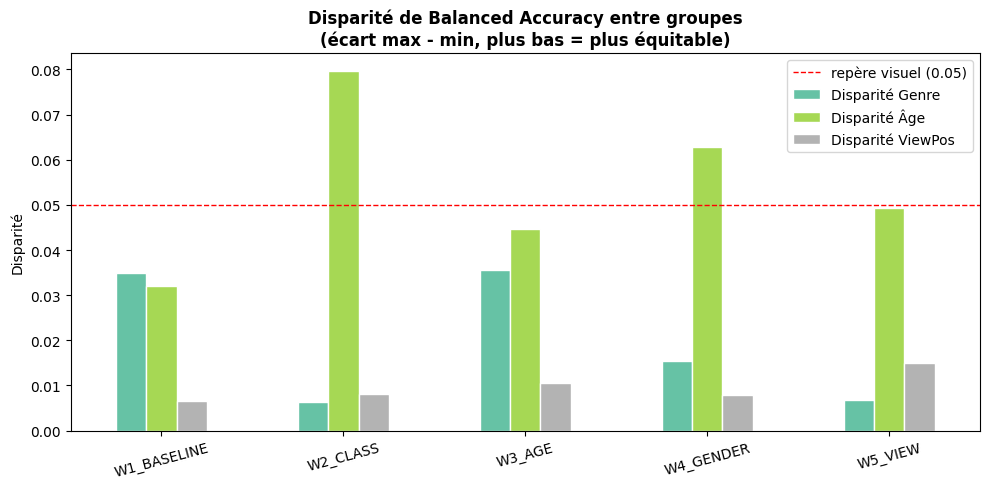

In [ ]:
# Disparités par stratégie de pondération
disparity_data = pd.DataFrame({
    name: {
        'Disparité Genre': m['disparity_Patient Gender'],
        'Disparité Âge': m['disparity_age_group'],
        'Disparité ViewPos': m['disparity_View Position'],
    }
    for name, m in all_metrics.items()
}).T

ax = disparity_data.plot(kind='bar', figsize=(10, 5), rot=15, edgecolor='white', colormap='Set2')
ax.set_title("Disparité de Balanced Accuracy entre groupes\n(écart max - min, plus bas = plus équitable)",
             fontweight='bold')
ax.set_ylabel('Disparité')
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1, label='repère visuel (0.05)')
ax.legend()
plt.tight_layout()
plt.savefig(f"{LOG_BASE}disparites.png", dpi=120, bbox_inches='tight')
plt.show()

Ce graphique confirme que l’**âge** est l’attribut pour lequel les écarts de performance sont les plus marqués. Pour toutes les stratégies de pondération, la disparité liée aux groupes d’âge reste supérieure à celle observée pour le genre ou la position de vue.

La stratégie **W3_AGE** est celle qui réduit le mieux cette disparité, ce qui est cohérent avec son objectif. Toutefois, cette amélioration ne suffit pas à ramener l’écart sous le repère visuel de 0.05, ce qui montre que le pré-traitement atténue le biais sans le faire disparaître complètement.

À l’inverse, **W2_CLASS** conserve une excellente performance globale, mais présente encore une disparité importante selon l’âge. Cela illustre bien qu’un modèle plus performant au niveau global n’est pas nécessairement le plus équitable entre sous-groupes.

Enfin, les disparités liées au **genre** et à la **position de vue** restent globalement plus faibles, ce qui suggère que le principal enjeu d’équité dans ce projet concerne avant tout l’âge.

### 5.2 Trade-off entre performance et équité

Un résultat central de ce projet est qu’il n’existe pas de stratégie optimale sur tous les critères à la fois. Certaines pondérations réduisent mieux les disparités entre groupes sensibles, mais au prix d’une légère baisse de balanced accuracy. À l’inverse, les modèles les plus performants globalement ne sont pas toujours les plus équitables sur chaque attribut.

Ce compromis est particulièrement visible pour l’âge : la stratégie **W3_AGE** améliore l’équité sur cet axe, mais reste légèrement moins performante que **W2_CLASS** ou **W4_GENDER** en accuracy globale.

Dans un contexte médical, ce trade-off doit être discuté avec prudence : une légère baisse de performance globale peut être acceptable si elle permet de réduire une inégalité importante entre sous-populations.

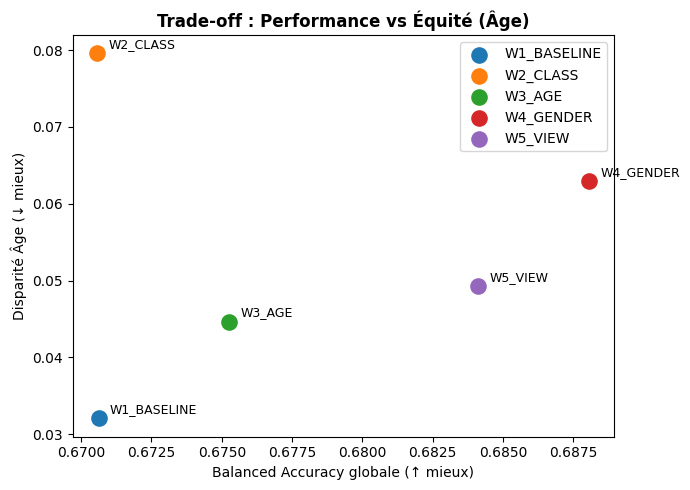

In [ ]:
# Trade-off : balanced accuracy globale vs disparité âge
fig, ax = plt.subplots(figsize=(7, 5))
for name, m in all_metrics.items():
    ax.scatter(
        m['balanced_accuracy'],
        m['disparity_age_group'],
        s=120, label=name, zorder=5
    )
    ax.annotate(name, (m['balanced_accuracy'], m['disparity_age_group']),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('Balanced Accuracy globale (↑ mieux)')
ax.set_ylabel("Disparité Âge (↓ mieux)")
ax.set_title("Trade-off : Performance vs Équité (Âge)", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f"{LOG_BASE}tradeoff_age.png", dpi=120, bbox_inches='tight')
plt.show()


### 5.3 Analyse du compromis entre performance et équité (âge)

Le graphique ci-dessus illustre le compromis entre la performance globale du modèle et la disparité entre groupes d’âge.

On observe qu’aucune stratégie ne domine sur les deux axes à la fois. Les modèles les plus performants ne sont pas les plus équitables, et inversement.

La stratégie **W2_CLASS** atteint la meilleure performance globale, mais présente une disparité élevée entre groupes d’âge. À l’inverse, **W3_AGE** est le modèle le plus équitable sur cet axe, mais au prix d’une baisse de performance.

La stratégie **W4_GENDER** apparaît comme un compromis intéressant, avec une performance élevée et une disparité modérée. Le modèle baseline se situe dans une position intermédiaire, tandis que **W5_VIEW** est dominé par les autres stratégies.

Ce résultat illustre clairement le compromis fondamental entre équité et performance : améliorer l’un de ces aspects peut dégrader l’autre. Le choix du modèle dépend donc du contexte d’application et des priorités retenues, notamment dans un cadre médical où la réduction des inégalités peut constituer un enjeu important.

## 6. Conclusion

Dans ce projet, nous avons étudié la présence de biais dans un classifieur basé sur ResNet18
appliqué au dataset NIH Chest X-Ray 14, puis exploré différentes stratégies pour les atténuer.

L'analyse initiale a mis en évidence des disparités entre groupes, en particulier selon l'**âge**,
qui constitue l'axe de biais le plus marqué. Les écarts liés au **genre** et à la **position de vue**
apparaissent plus faibles, mais restent présents.

Plusieurs stratégies de **pré-traitement** ont été évaluées via des schémas de pondération.
Les résultats montrent que certaines approches, notamment **W3_AGE**, permettent de réduire
les disparités entre groupes d'âge. Toutefois, cette amélioration s'accompagne d'une légère
diminution de la performance globale, illustrant un **compromis classique entre équité et accuracy**.
À l'inverse, des stratégies comme **W2_CLASS** offrent une meilleure performance globale,
mais au prix d'inégalités plus importantes.

Le **post-traitement**, via l'ajustement du seuil de décision, permet d'améliorer légèrement
la balanced accuracy sans réentraîner le modèle. L'égalisation des opportunités, appliquée
séparément par groupe d'âge, réduit davantage les inégalités de détection entre sous-populations,
mais au prix d'une légère baisse de performance globale. Une analyse exploratoire des combinaisons
pré × post-traitement montre que certaines configurations, notamment autour de **W2_CLASS**,
offrent les meilleures performances globales, sans pour autant éliminer complètement les disparités.

En termes de biais détectés et corrigés : l'âge constitue l'axe le plus problématique, avec
les patients de plus de 60 ans présentant un taux de maladie de **53.8%** contre **36.4%**
pour les moins de 40 ans. Cette disparité se retrouve dans les prédictions du modèle.
Le pré-traitement **W3_AGE** permet de réduire l'écart de disparité de **0.0725 à 0.0424**,
sans toutefois l'éliminer complètement. Le post-traitement par égalisation des opportunités
réduit davantage l'EOD, confirmant l'intérêt d'une approche orientée fairness au moment
de la décision. Le biais lié au **genre** et à la **position de vue** reste plus faible
et plus facile à corriger par pondération.

Ces résultats confirment qu'il n'existe pas de solution unique permettant d'optimiser
simultanément équité et performance. Le choix du modèle dépend donc du contexte d'application.
Dans un cadre médical, il peut être pertinent d'accepter une légère baisse de performance
globale afin de limiter les inégalités entre populations, en particulier lorsque celles-ci
concernent des groupes vulnérables.

Enfin, ce travail présente plusieurs limites. Le modèle n'exploite que les images et non
les métadonnées, ce qui peut conduire à l'apprentissage implicite de caractéristiques sensibles.
De plus, les méthodes utilisées restent relativement simples. Des approches plus avancées,
telles que les techniques d'**in-processing** ou des contraintes explicites de fairness,
pourraient être explorées pour aller plus loin.